# CE49X Lab 6: Can We Predict Heart Disease?
## Machine Learning for Medical Diagnosis

**Instructor:** Dr. Eyuphan Koc  
**Department of Civil Engineering, Bogazici University**  
**Semester:** Spring 2026

---

**Student Name:**  
**Student ID:**  
**AI Assistance:** *(Document any AI tools used and how)*

## Background

Cardiovascular diseases are the **leading cause of death globally**, responsible for approximately 17.9 million deaths per year (WHO, 2021). Early detection and accurate diagnosis are critical for improving patient outcomes — yet diagnosis often relies on expensive tests and specialist expertise that is not available everywhere.

Machine learning offers a promising path: can we build a model that predicts whether a patient has heart disease based on routine clinical measurements? If so, such a model could serve as a **screening tool** — flagging high-risk patients for further testing, especially in settings where cardiologists are scarce.

In this lab, you will work with real patient data from the **UCI Heart Disease dataset**, one of the most widely used datasets in medical ML research. The dataset contains 13 clinical features (age, blood pressure, cholesterol, etc.) and a binary label indicating whether heart disease was diagnosed.

> **Key Insight:** This is a **high-stakes classification problem**. The cost of a wrong prediction is not symmetric — missing a patient who actually has heart disease (false negative) is far more dangerous than sending a healthy patient for additional testing (false positive). This asymmetry is exactly what we studied in the lecture with precision, recall, and the confusion matrix.

## Scenario

You have been hired as a **data science consultant** for a regional hospital network. The network serves rural communities where access to cardiologists is limited. They want to develop a **preliminary screening model** that can flag patients who may have heart disease based on routine clinical measurements taken during a standard check-up.

Your task is to:
1. Explore and understand the clinical data
2. Train and compare classification models
3. Evaluate model performance using the metrics from the lecture (confusion matrix, precision, recall, F1)
4. Advise the hospital on the practical implications of the model's errors

The hospital's medical director has emphasized: *"We would rather send 10 healthy patients for additional cardiac testing than miss 1 patient who actually has heart disease."*

## Dataset Description

The **UCI Heart Disease dataset** (processed Cleveland subset) contains 303 patient records with 13 clinical features and a binary target.

| Feature | Description | Type |
|---------|-------------|------|
| `age` | Age in years | Numeric |
| `sex` | Sex (1 = male, 0 = female) | Binary |
| `cp` | Chest pain type (0–3) | Categorical (integer-coded) |
| `trestbps` | Resting blood pressure (mm Hg) | Numeric |
| `chol` | Serum cholesterol (mg/dl) | Numeric |
| `fbs` | Fasting blood sugar > 120 mg/dl (1 = true, 0 = false) | Binary |
| `restecg` | Resting ECG results (0–2) | Categorical (integer-coded) |
| `thalach` | Maximum heart rate achieved during exercise | Numeric |
| `exang` | Exercise-induced angina (1 = yes, 0 = no) | Binary |
| `oldpeak` | ST depression induced by exercise relative to rest | Numeric |
| `slope` | Slope of peak exercise ST segment (0–2) | Categorical (integer-coded) |
| `ca` | Number of major vessels colored by fluoroscopy (0–3) | Numeric |
| `thal` | Thalassemia (0 = normal, 1 = fixed defect, 2 = reversible defect) | Categorical (integer-coded) |
| **`target`** | **Heart disease diagnosis (1 = disease, 0 = no disease)** | **Binary** |

> **Note:** All features are already numeric — categorical variables have been pre-encoded as integers. You do **not** need to perform any encoding for this lab. Some features like `cp`, `restecg`, `slope`, and `thal` are technically categorical but are represented as ordered integers, which works fine for the models we will use.

## Deliverables Overview

| # | Title | Points | Key Techniques |
|---|-------|--------|----------------|
| D1 | Data Loading & Exploration | 20 | `pd.read_csv`, `df.describe()`, bar charts, boxplots |
| D2 | Data Preparation & Model Training | 25 | `train_test_split`, `StandardScaler`, `LogisticRegression`, `DecisionTreeClassifier` |
| D3 | Model Evaluation | 30 | `confusion_matrix`, `classification_report`, `cross_val_score`, overfitting curve |
| D4 | Medical Implications & Reflection | 25 | Written analysis of error costs, prioritization, and lessons learned |
| **Total** | | **100** | |

**Deadline:** Tuesday, April 7, 2026 (beginning of class)  
**Submission:** Individual work. Rename this notebook to `Week06_Lab_FirstnameLastname.ipynb`, commit and push to your fork.

---
## Your Work Starts Here

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, f1_score)
import time
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

---
## Deliverable 1: Data Loading & Exploration (20 pts)

### Instructions

1. **Load the dataset** using the code cell below (it downloads directly from the UCI repository — no signup needed)
2. **Explore the data:**
   - Print `df.shape`, `df.info()`, and `df.describe()`
   - Check for missing values
3. **Create at least 3 visualizations:**
   - A bar chart showing the distribution of the target variable (how many patients have heart disease vs. don't)
   - At least 1 plot exploring a **numeric feature** across the two classes (e.g., boxplot of `age` grouped by `target`, or histogram of `thalach` colored by diagnosis)
   - At least 1 plot exploring a **second feature** of your choice (e.g., bar chart of `cp` counts by target, scatter plot of `age` vs `thalach` colored by target)
4. **Written observation** (1 paragraph in a markdown cell): What patterns do you notice? Which features seem related to heart disease?

| Criterion | Points |
|---|---|
| Data loaded, shape and info printed | 3 |
| Missing values checked and handled | 3 |
| 3+ well-labeled exploration plots | 8 |
| Written observation paragraph | 6 |

> **Key Insight:** The target variable is roughly balanced (~54% no disease, ~46% disease). This means a model that always predicts "no disease" would only be right about 54% of the time. Keep this baseline in mind — any useful model must beat it.

In [2]:
# Load the UCI Heart Disease dataset (Cleveland subset)
# This downloads directly from the UCI ML Repository - no account needed

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data'

columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
           'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

df = pd.read_csv(url, names=columns, na_values='?')

# The original target has values 0-4 (severity levels).
# We binarize: 0 = no heart disease, 1 = heart disease present
df['target'] = (df['target'] > 0).astype(int)

# TIP: If the URL doesn't work, download the file manually from
# https://archive.ics.uci.edu/dataset/45/heart+disease
# Save it as 'data/processed.cleveland.data' and load with:
# df = pd.read_csv('data/processed.cleveland.data', names=columns, na_values='?')

print(f"Dataset shape: {df.shape}")
print(f"\nFirst 5 rows:")
df.head()

Dataset shape: (303, 14)

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [3]:
# Basic exploration: shape, info, summary statistics, missing values
print(f"Dataset shape: {df.shape}")
print("\nDataFrame info:")
df.info()

print("\nSummary statistics:")
display(df.describe())

print("\nMissing values per column:")
print(df.isnull().sum())

print(f"\nTotal missing values in dataset: {df.isnull().sum().sum()}")


Dataset shape: (303, 14)

DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int32  
dtypes: float64(13), int32(1)
memory usage: 32.1 KB

Summary statistics:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,0.499120
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000



Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

Total missing values in dataset: 6


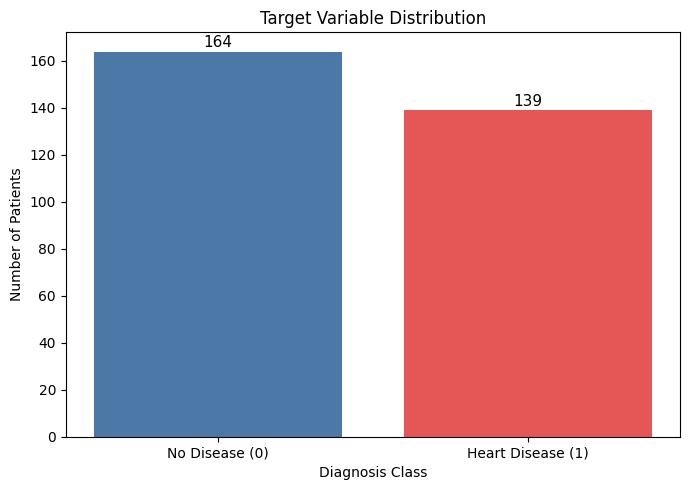

Class proportions:
target
0    0.541
1    0.459
Name: count, dtype: float64


In [4]:
# Plot 1: Target variable distribution (bar chart)
target_counts = df['target'].value_counts().sort_index()
labels = ['No Disease (0)', 'Heart Disease (1)']

plt.figure(figsize=(7, 5))
plt.bar(labels, target_counts.values, color=['#4C78A8', '#E45756'])
plt.title('Target Variable Distribution')
plt.xlabel('Diagnosis Class')
plt.ylabel('Number of Patients')

for i, v in enumerate(target_counts.values):
    plt.text(i, v + 2, str(v), ha='center', fontsize=11)

plt.tight_layout()
plt.show()

print('Class proportions:')
print((target_counts / target_counts.sum()).round(3))


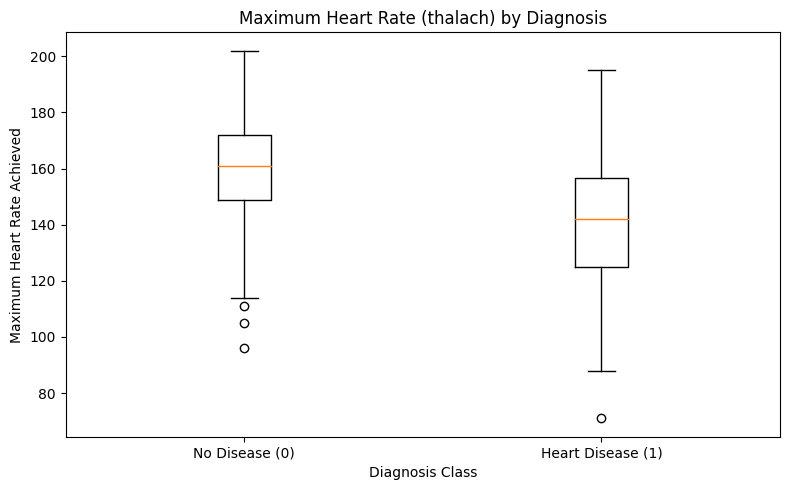

In [5]:
# Plot 2: Numeric feature across classes (thalach by target)
plt.figure(figsize=(8, 5))

thalach_no = df[df['target'] == 0]['thalach']
thalach_yes = df[df['target'] == 1]['thalach']

plt.boxplot([thalach_no, thalach_yes], labels=['No Disease (0)', 'Heart Disease (1)'])
plt.title('Maximum Heart Rate (thalach) by Diagnosis')
plt.xlabel('Diagnosis Class')
plt.ylabel('Maximum Heart Rate Achieved')
plt.tight_layout()
plt.show()


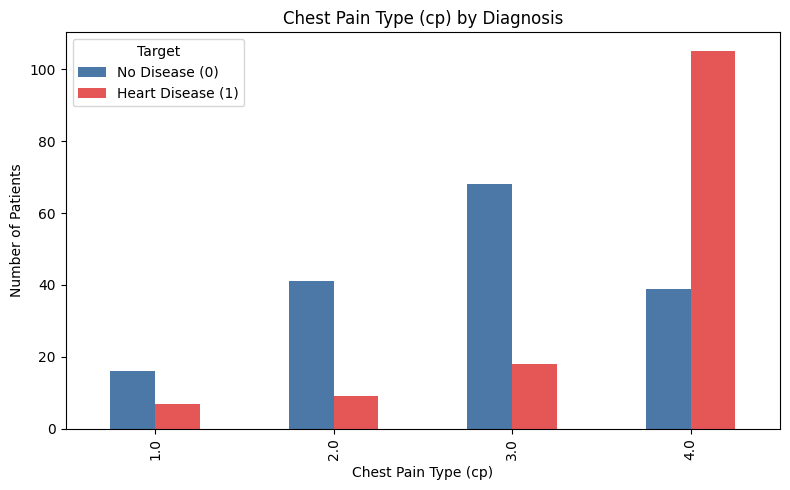

In [6]:
# Plot 3: Chest pain type distribution by diagnosis (cp vs target)
cp_target = pd.crosstab(df['cp'], df['target'])

cp_target.plot(kind='bar', figsize=(8, 5), color=['#4C78A8', '#E45756'])
plt.title('Chest Pain Type (cp) by Diagnosis')
plt.xlabel('Chest Pain Type (cp)')
plt.ylabel('Number of Patients')
plt.legend(['No Disease (0)', 'Heart Disease (1)'], title='Target')
plt.tight_layout()
plt.show()


### Observation

The target distribution is relatively balanced, so a trivial baseline model would not be sufficient. From the feature plots, patients diagnosed with heart disease tend to have lower `thalach` (maximum heart rate achieved) compared with the no-disease group, suggesting reduced exercise capacity may be associated with disease presence. The chest pain variable (`cp`) also appears informative: some chest pain categories are much more frequent in the heart-disease class than in the healthy class. Overall, `thalach` and `cp` look like strong candidate predictors, and these early patterns justify moving to model-based analysis in the next deliverables.


---
## Deliverable 2: Data Preparation & Model Training (25 pts)

### Instructions

1. **Handle missing values.** Drop any rows with missing values (there should be very few). Print the shape before and after.

2. **Separate features and target:**
   - `X` = all columns except `target`
   - `y` = the `target` column

3. **Train-test split:** Split into 80% training / 20% test using `train_test_split` with `stratify=y` and `random_state=42`. Print the shapes of `X_train`, `X_test`, `y_train`, `y_test`.

4. **Scale the features** using `StandardScaler`:
   - Fit the scaler on `X_train` only
   - Transform both `X_train` and `X_test`
   - **[REQUIRED] Markdown cell:** Why must we fit the scaler on the training data only? What would go wrong if we fit it on the entire dataset before splitting? *(Connect this to the data leakage concept from the lecture.)*

5. **Train two classifiers:**
   - `LogisticRegression(max_iter=1000, random_state=42)`
   - `DecisionTreeClassifier(random_state=42)`

6. For each model, report:
   - Training accuracy
   - Test accuracy
   - Training time (use `time.time()` before and after `model.fit()`)

7. **[REQUIRED] Markdown cell:** Create a comparison summary. Which model performs better on the test set? Is either model overfitting? How can you tell from the train vs. test accuracy gap?

| Criterion | Points |
|---|---|
| Missing values handled, shapes printed | 2 |
| Train-test split with stratification | 3 |
| Scaling done correctly (fit on train only) | 3 |
| Data leakage explanation (own words) | 4 |
| Both models trained, all metrics reported | 6 |
| Comparison + overfitting discussion | 7 |

> **Key Insight:** If your Decision Tree achieves near-100% training accuracy but much lower test accuracy, it has memorized the training data. This is overfitting — the central danger from Section 7 of the lecture. The gap between training and test accuracy is your overfitting signal.

In [17]:
# Handle missing values
print(f"Shape before dropping missing values: {df.shape}")
print("\nMissing values per column:")
print(df.isnull().sum())

df = df.dropna()

print(f"\nShape after dropping missing values:  {df.shape}")
print(f"Rows removed: {303 - df.shape[0]}")


Shape before dropping missing values: (303, 14)

Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

Shape after dropping missing values:  (297, 14)
Rows removed: 6


In [18]:
# Separate features (X) and target (y), then train-test split
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")


X_train shape: (237, 13)
X_test shape:  (60, 13)
y_train shape: (237,)
y_test shape:  (60,)


In [19]:
# Scale features with StandardScaler
# IMPORTANT: fit on X_train only, then transform both X_train and X_test
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)   # fit + transform on training data
X_test_scaled = scaler.transform(X_test)         # transform only on test data

print("Scaling completed.")
print(f"Scaled X_train shape: {X_train_scaled.shape}")
print(f"Scaled X_test shape:  {X_test_scaled.shape}")


Scaling completed.
Scaled X_train shape: (237, 13)
Scaled X_test shape:  (60, 13)


### Data Leakage Explanation

We must fit `StandardScaler` on the training set only, because scaling learns statistics (mean and standard deviation) from the data. If we fit on the full dataset before splitting, information from the test set leaks into training through those statistics. This is data leakage: the model indirectly "sees" the test distribution during training, so evaluation becomes overly optimistic and no longer reflects true generalization performance on unseen patients.


In [20]:
# Train Logistic Regression and report metrics
log_reg = LogisticRegression(max_iter=1000, random_state=42)

start = time.time()
log_reg.fit(X_train_scaled, y_train)
log_reg_train_time = time.time() - start

log_reg_train_acc = log_reg.score(X_train_scaled, y_train)
log_reg_test_acc = log_reg.score(X_test_scaled, y_test)

print("Logistic Regression Results")
print(f"Training accuracy: {log_reg_train_acc:.4f}")
print(f"Test accuracy:     {log_reg_test_acc:.4f}")
print(f"Training time:     {log_reg_train_time:.4f} seconds")


Logistic Regression Results
Training accuracy: 0.8523
Test accuracy:     0.8333
Training time:     0.0030 seconds


In [21]:
# Train Decision Tree and report metrics
decision_tree = DecisionTreeClassifier(random_state=42)

start = time.time()
decision_tree.fit(X_train_scaled, y_train)
decision_tree_train_time = time.time() - start

decision_tree_train_acc = decision_tree.score(X_train_scaled, y_train)
decision_tree_test_acc = decision_tree.score(X_test_scaled, y_test)

print("Decision Tree Results")
print(f"Training accuracy: {decision_tree_train_acc:.4f}")
print(f"Test accuracy:     {decision_tree_test_acc:.4f}")
print(f"Training time:     {decision_tree_train_time:.4f} seconds")


Decision Tree Results
Training accuracy: 1.0000
Test accuracy:     0.6833
Training time:     0.0030 seconds


### Model Comparison

In this run, **Logistic Regression** performs better on the test set (about **0.83** test accuracy), while the **Decision Tree** gets a lower test accuracy (about **0.68**). The Decision Tree also shows clear overfitting: its training accuracy is near **1.00**, but test accuracy drops substantially, creating a large train-test gap. In contrast, Logistic Regression has a much smaller gap between training and test accuracy, which suggests better generalization to unseen patients.


---
## Deliverable 3: Model Evaluation (30 pts)

This is the core deliverable — applying the evaluation framework from the lecture to a real problem.

### Instructions

#### Part A: Confusion Matrix (8 pts)

For the **better-performing model** from D2:
1. Compute the confusion matrix using `confusion_matrix(y_test, y_pred)`
2. Visualize it as a **heatmap** (see the Hints section for code)
3. Label the axes clearly: "No Disease (0)" and "Heart Disease (1)"
4. **[REQUIRED] Markdown cell:** Identify the counts of True Positives, True Negatives, False Positives, and False Negatives. In the medical context, what does each one mean?

#### Part B: Classification Report (7 pts)

1. Print the full `classification_report(y_test, y_pred)`
2. **[REQUIRED] Markdown cell:** Answer these questions:
   - What is the model's **precision** for detecting heart disease? What does this number mean in plain English?
   - What is the model's **recall** for detecting heart disease? What does this number mean?
   - Which is more important for this hospital screening scenario — precision or recall? Why?

#### Part C: Cross-Validation (6 pts)

1. Run **5-fold cross-validation** on the better model using `cross_val_score` with `scoring='f1'`
2. Report the **mean** and **standard deviation** of the F1 scores across folds
3. **[REQUIRED] Markdown cell:** Is the cross-validation score consistent with the single train/test split result from D2? What would a high standard deviation across folds suggest?

#### Part D: The Overfitting Curve (9 pts)

1. Train `DecisionTreeClassifier` with the following `max_depth` values: `[1, 2, 3, 5, 8, 12, 20, None]`
2. For each value, compute both **training accuracy** and **test accuracy**
3. **Plot** training accuracy and test accuracy vs. `max_depth` on the same axes (use different colors and a legend)
4. **[REQUIRED] Markdown cell:** What is the best `max_depth` value? What happens when the tree is too shallow (underfitting)? What happens when it is too deep (overfitting)? Connect this to the lecture.

| Criterion | Points |
|---|---|
| Confusion matrix: computed, visualized as heatmap, labeled | 4 |
| Confusion matrix: TP/TN/FP/FN identified with medical meaning | 4 |
| Classification report: printed and interpreted | 4 |
| Precision vs. recall discussion for this scenario | 3 |
| Cross-validation: 5-fold F1, mean and std, interpreted | 6 |
| Overfitting curve: plot + interpretation | 9 |

Confusion matrix:
 [[28  4]
 [ 6 22]]


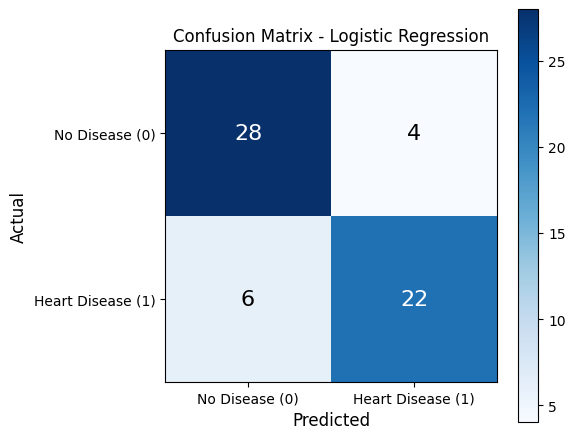

In [27]:
# Part A: Confusion matrix for the better model (Logistic Regression from D2)
# Generate predictions
y_pred_best = log_reg.predict(X_test_scaled)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred_best)
print("Confusion matrix:\n", cm)

# Visualize as a heatmap
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')

# Add count annotations
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=16,
                color='white' if cm[i, j] > cm.max() / 2 else 'black')

ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_xticks([0, 1])
ax.set_xticklabels(['No Disease (0)', 'Heart Disease (1)'])
ax.set_yticks([0, 1])
ax.set_yticklabels(['No Disease (0)', 'Heart Disease (1)'])
ax.set_title('Confusion Matrix - Logistic Regression')
plt.colorbar(im)
plt.tight_layout()
plt.show()


### Confusion Matrix Interpretation

- **True Positives (TP):** 22 patients — model predicts heart disease and the patient truly has heart disease.
- **True Negatives (TN):** 28 patients — model predicts no disease and the patient is truly healthy.
- **False Positives (FP):** 4 patients — model flags heart disease, but the patient is actually healthy (extra follow-up burden).
- **False Negatives (FN):** 6 patients — model predicts no disease, but the patient actually has heart disease (most dangerous error in this context).


In [28]:
# Part B: Classification report
print("Classification report for Logistic Regression:\n")
print(classification_report(y_test, y_pred_best, digits=4))


Classification report for Logistic Regression:

              precision    recall  f1-score   support

           0     0.8235    0.8750    0.8485        32
           1     0.8462    0.7857    0.8148        28

    accuracy                         0.8333        60
   macro avg     0.8348    0.8304    0.8316        60
weighted avg     0.8341    0.8333    0.8328        60



### Classification Report Interpretation

- **Precision for heart disease (class 1):** about **0.8462**. In plain English: when the model says "heart disease," it is correct about 85% of the time.
- **Recall for heart disease (class 1):** about **0.7857**. In plain English: the model catches about 79% of truly diseased patients, but misses about 21%.
- **Which is more important here — precision or recall?** For this hospital screening scenario, **recall** is more important because missing a truly sick patient (false negative) is medically more dangerous than referring a healthy patient for extra testing.


In [29]:
# Part C: 5-fold cross-validation
cv_model = LogisticRegression(max_iter=1000, random_state=42)
cv_scores = cross_val_score(cv_model, X_train_scaled, y_train, cv=5, scoring='f1')

print(f"F1 scores per fold: {cv_scores}")
print(f"Mean F1: {cv_scores.mean():.4f}")
print(f"Std F1:  {cv_scores.std():.4f}")


F1 scores per fold: [0.93023256 0.86956522 0.8        0.73170732 0.64864865]
Mean F1: 0.7960
Std F1:  0.0993


### Cross-Validation Interpretation

The 5-fold CV result (mean F1 about **0.7960**, std about **0.0993**) is broadly consistent with the single train/test split: performance is reasonably good but not perfect. The non-trivial standard deviation suggests model performance changes across different train/validation partitions, which may indicate sensitivity to sample composition and limited dataset size. If the variance were very high, it would suggest unstable generalization and lower confidence in a single split result.


In [30]:
# Part D: Overfitting curve - Decision Tree with varying max_depth

depths = [1, 2, 3, 5, 8, 12, 20, None]
train_accs = []
test_accs = []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train_scaled, y_train)
    train_accs.append(dt.score(X_train_scaled, y_train))
    test_accs.append(dt.score(X_test_scaled, y_test))

print("Depths:", depths)
print("Train accuracies:", [round(v, 4) for v in train_accs])
print("Test accuracies: ", [round(v, 4) for v in test_accs])


Depths: [1, 2, 3, 5, 8, 12, 20, None]
Train accuracies: [0.7637, 0.7848, 0.8439, 0.9072, 1.0, 1.0, 1.0, 1.0]
Test accuracies:  [0.7667, 0.7167, 0.8, 0.7, 0.6833, 0.6833, 0.6833, 0.6833]


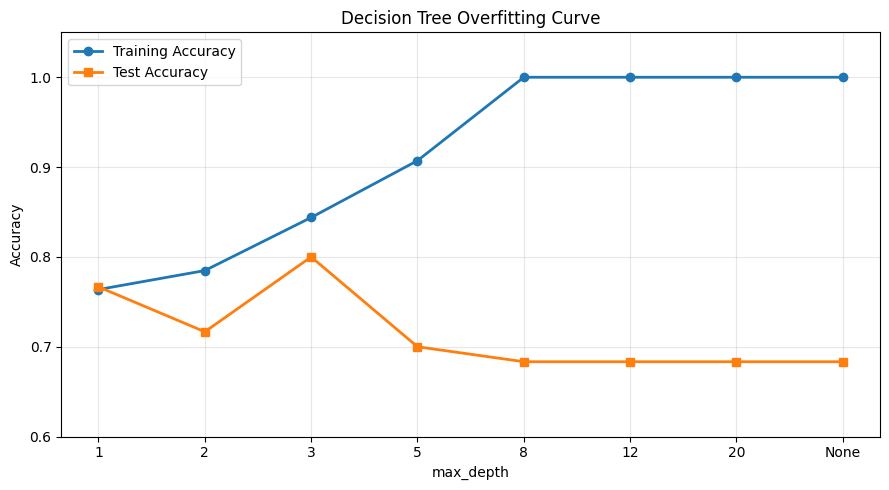

In [31]:
# Plot the overfitting curve: train and test accuracy vs max_depth
depth_labels = [str(d) if d is not None else 'None' for d in depths]
x = np.arange(len(depths))

plt.figure(figsize=(9, 5))
plt.plot(x, train_accs, marker='o', linewidth=2, label='Training Accuracy')
plt.plot(x, test_accs, marker='s', linewidth=2, label='Test Accuracy')
plt.xticks(x, depth_labels)
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree Overfitting Curve')
plt.ylim(0.6, 1.05)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


### Overfitting Curve Interpretation

From this run, the best test accuracy is at **max_depth = 3** (about **0.80**). When the tree is too shallow (for example depth 1), it cannot capture enough structure in the data, so both train and test performance stay limited (underfitting). As depth increases too much (8, 12, 20, or None), training accuracy reaches 1.00 while test accuracy drops to about 0.68, which is a clear overfitting pattern. This matches the lecture concept: increasing model complexity reduces bias at first, then increases variance and harms generalization.


---
## Deliverable 4: Medical Implications & Reflection (25 pts)

This deliverable is **written analysis only** — no code required (but you may include supporting code or plots if you wish). Answer **all four questions** in the markdown cells below.

### Instructions

| Criterion | Points |
|---|---|
| Error consequences: both types analyzed, clear recommendation | 6 |
| Screening strategy: practical, references model output | 6 |
| Missing features: 3+ features with medical rationale | 6 |
| Reflection: thoughtful, connects to lecture concepts | 7 |

### Question 1: Error Consequences (6 pts)

Consider these two types of model errors:

- **Type A (False Negative):** The model predicts "No Disease" but the patient actually **has** heart disease.
- **Type B (False Positive):** The model predicts "Heart Disease" but the patient is actually **healthy**.

Which type of error is more dangerous? Which type wastes more hospital resources? If you were advising the hospital, which type of error would you prioritize reducing, and why? *(1 paragraph)*

---

False negatives are clearly more dangerous because they can delay diagnosis and treatment for a patient who truly has heart disease, potentially leading to severe outcomes such as myocardial infarction or death. False positives mainly waste resources by sending healthy patients to additional tests, increasing cost, workload, and patient anxiety, but they are usually safer medically than missed disease. If advising the hospital, I would prioritize reducing false negatives first (improving recall for class 1), even if this slightly increases false positives, because the clinical risk of missing a real case is much higher than the operational cost of extra follow-up.


### Question 2: Screening Strategy (6 pts)

The hospital has capacity to refer only **50 patients per month** for advanced cardiac testing (stress tests, angiograms, etc.). In a typical month, they see 300 patients for routine check-ups.

Using your model's predictions, describe a strategy to select which 50 patients to refer. Would you trust the model's predictions on their own, or would you combine them with other information? *(1 paragraph)*

---

I would rank all 300 patients by predicted probability of heart disease (not only by hard 0/1 labels) and refer the top 50 highest-risk patients each month. To reduce missed critical cases, I would also include a clinical override rule: patients with red-flag symptoms (severe chest pain, strong ECG abnormalities, very high blood pressure, prior cardiac history) are prioritized even if their model score is slightly below the cutoff. So, I would not rely on the model alone; I would combine model output with physician judgment and key clinical indicators to create a safer and more practical triage strategy.


### Question 3: Missing Information (6 pts)

Name at least **3 features** that are NOT in this dataset but would likely improve the model's ability to predict heart disease. For each, briefly explain why it would be useful. *(Bullet points)*

---

- **Family history of premature cardiovascular disease:** Captures inherited risk that may not be visible in current vital signs.
- **Smoking exposure (current status + pack-years):** Strong causal risk factor for atherosclerosis and coronary disease severity.
- **Body mass index (BMI) / waist circumference:** Reflects obesity-related cardiometabolic risk not directly represented by the current variables.
- **Diabetes markers (HbA1c or fasting glucose level as continuous value):** Better measures long-term metabolic risk than only a binary fasting blood sugar flag.
- **Kidney function (creatinine/eGFR):** Chronic kidney disease is associated with elevated cardiovascular risk and poor outcomes.


### Question 4: Reflection (7 pts)

What was the most surprising or interesting thing you learned in this lab about how ML models are evaluated? Before this lab, would you have trusted a model that reports "85% accuracy"? How has your understanding changed? *(1–2 paragraphs)*

---

The most interesting lesson for me was that a single metric like accuracy can hide clinically important errors. Two models can have similar overall accuracy but very different false-negative behavior, and in a medical screening task that difference is critical. Looking at confusion matrix entries, precision, recall, and F1 made the evaluation much more meaningful than accuracy alone.

Before this lab, I might have trusted a model that reports 85% accuracy without asking many questions. Now I see that this is not enough: we must check class balance, error types, train-test gap (overfitting risk), and cross-validation stability. In a high-stakes application, model evaluation should be tied to real decision costs, not just headline performance.


---
## Hints

### Handling Missing Values

```python
print(f"Missing values per column:\n{df.isnull().sum()}")
print(f"\nShape before: {df.shape}")
df = df.dropna()
print(f"Shape after:  {df.shape}")
```

### Train-Test Split with Stratification

```python
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
```

### StandardScaler (Fit on Train Only!)

```python
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit AND transform on train
X_test_scaled = scaler.transform(X_test)          # only transform on test
```

### Timing Model Training

```python
start = time.time()
model.fit(X_train_scaled, y_train)
train_time = time.time() - start
print(f"Training time: {train_time:.4f} seconds")
```

### Confusion Matrix Heatmap

```python
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')

# Add count annotations
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=18,
                color='white' if cm[i, j] > cm.max()/2 else 'black')

ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_xticks([0, 1])
ax.set_xticklabels(['No Disease (0)', 'Heart Disease (1)'])
ax.set_yticks([0, 1])
ax.set_yticklabels(['No Disease (0)', 'Heart Disease (1)'])
ax.set_title('Confusion Matrix')
plt.colorbar(im)
plt.tight_layout()
plt.show()
```

### Cross-Validation

```python
scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='f1')
print(f"F1 scores per fold: {scores}")
print(f"Mean F1: {scores.mean():.4f} (+/- {scores.std():.4f})")
```

### Overfitting Curve

```python
depths = [1, 2, 3, 5, 8, 12, 20, None]
train_accs = []
test_accs = []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train_scaled, y_train)
    train_accs.append(dt.score(X_train_scaled, y_train))
    test_accs.append(dt.score(X_test_scaled, y_test))

# For plotting, replace None with a label
depth_labels = [str(d) if d is not None else 'None' for d in depths]
```

---
## Grading

| Component | Points |
|-----------|--------|
| D1: Data Loading & Exploration | 20 |
| D2: Data Preparation & Model Training | 25 |
| D3: Model Evaluation | 30 |
| D4: Medical Implications & Reflection | 25 |
| **Total** | **100** |

### Deductions

| Issue | Penalty |
|-------|---------|
| Notebook doesn't run top-to-bottom | -10 |
| Scaling before train-test split (data leakage) | -5 |
| Missing axis labels or units on plots (per deliverable) | -3 |
| No stratification in train-test split | -3 |
| No `random_state` set (results not reproducible) | -3 |
| Missing AI assistance acknowledgment (if used) | -2 |

## Submission

This lab is **individual work**.

1. Rename this notebook to `Week06_Lab_FirstnameLastname.ipynb`
2. Make sure your notebook **runs from top to bottom without errors** (Kernel → Restart & Run All)
3. Commit and push to your fork:

```bash
git add Week06_Machine_Learning_Introduction/lab/Week06_Lab_FirstnameLastname.ipynb
git commit -m "Submit Week 06 lab - Heart Disease Prediction"
git push origin main
```

4. **Deadline:** Tuesday, April 7, 2026 (beginning of class)
5. **Late policy:** 10% penalty per day, maximum 3 days late

---

### Questions?

**Dr. Eyuphan Koc**  
eyuphan.koc@bogazici.edu.tr